In [29]:
# <import your dependencies here>
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_score  


# Edit this section

* Load_data:
    * load data from csv using `\t` as the separator.
    * Drop irrelevant columns
    * Label encode
    * select the main features and make an array of values (an array of arrays)
        * Example format of this:
            * `x = data_main[['Education', 'Kidhome', 'Teenhome' ......
                   'Z_CostContact', 'Z_Revenue']].values`
    * Scalarization of the features
    * return `scaled_x` variable which is a variable containing the scaled values of x

* apply_pca:
    * return `x_pca` variable which is the set of reduced features.
    * for ideal results, use n_components as 2. Feel free to experiment with this value but n_components = 2 is ideal case.

* find_optimal_clusters:
    * this is to find the optimal number of clusters using the elbow method.
    * find the values of inertia till max_clusters+1 and append the inertia values to an array.
    * return the inertia array with `inertia` variable. `VERY IMPORTANT TO SEE THE GRAPH`

* perform_kmeans_clustering:
    * use kmeans `init = "k-means++"`, `max_iter=300`, `n_init = 10`, `random_state` is your choice and `n_clusters` is the best elbow value.
    * return the kmeans fit predict values with `y_kmeans` variable.

* perform_agglomerative_clustering:
    * Linkage method is "ward" and n_clusters is the best elbow value.
    * return the agglomerative clustering values after fit predicting the `x` feature values as `y_agglomerative` variable name.

* for dendrogram:
    * get_linkages:
        * it helps to form the linkages between x and in the 'ward' method.
        * return `linked` variable which has the linkages.
    * plot_dendrogram:
        * it is to plot the dendrogram in the (10,7) with x_label as index and y_label as distance
        * dendrogram function takes in the linkages from `get_linkages` function as the `linked` variable.

* Now, you are requested to submit screenshots of the `dengrogram, test case 1 and 2 passed messages`.

In [30]:
def load_data(path):
    # Load data from CSV file
    data = pd.read_csv(path, sep='\t')
    
    # Print column names to identify irrelevant columns, if any
    print("Columns in dataset:", data.columns.tolist())
    
    # Drop irrelevant columns if needed (update the list with actual names or skip if none)
    
    # Label encode non-numerical columns
    label_encoder = LabelEncoder()
    for column in data.select_dtypes(include=['object']).columns:
        data[column] = label_encoder.fit_transform(data[column])
    
    # Select main features and form a feature vector
    x = data[['Education', 'Kidhome', 'Teenhome', 'Z_CostContact', 'Z_Revenue']].values
    
    # Scale features
    scaler = StandardScaler()
    scaled_x = scaler.fit_transform(x)
    
    return scaled_x


def apply_pca(x, n_components=2):
    # Perform PCA for dimensionality reduction
    pca = PCA(n_components=n_components)
    x_pca = pca.fit_transform(x)
    
    return x_pca

#================ FOR K-Means ===============================
# Find Optimal Clusters for KMeans (Elbow Method) 
# Global variable to store optimal number of clusters
n_clusters = None

# Find Optimal Clusters for KMeans (Elbow Method) 
def find_optimal_clusters(x, max_clusters=10):
    global n_clusters
    inertia = []
    
    # Calculate inertia for a range of cluster counts
    for n in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(x)
        inertia.append(kmeans.inertia_)
    
    # Plot inertia vs. number of clusters
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, max_clusters + 1), inertia, marker='o')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal Clusters')
    plt.show()
    
    # Assign a value to n_clusters based on the "elbow" point
    n_clusters = 3  # Replace with logic if you have a method to select the optimal cluster
    
    return inertia

# Perform KMeans Clustering using global n_clusters
def perform_kmeans_clustering(x):
    global n_clusters
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(x)
    return labels

# Perform Agglomerative Clustering using global n_clusters
def perform_agglomerative_clustering(x):
    global n_clusters
    agglomerative = AgglomerativeClustering(linkage='ward', n_clusters=n_clusters)
    labels = agglomerative.fit_predict(x)
    return labels

#================FOR Dendrogram===============================
# Get Linkages for Dendrogram
def get_linkages(x):
    # Calculate linkages for dendrogram
    linkages = linkage(x, method='ward')
    
    return linkages

# Plot Dendrogram
def plot_dendrogram(linked):
    # Plot dendrogram
    plt.figure(figsize=(10, 6))
    dendrogram(linked)
    plt.title('Dendrogram')
    plt.xlabel('Data points')
    plt.ylabel('Distance')
    plt.show()


# Just edit the file path here... Don't edit anything else

In [31]:
def calculate_silhouette_score(x, y_pred):
    return silhouette_score(x, y_pred)

Columns in dataset: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


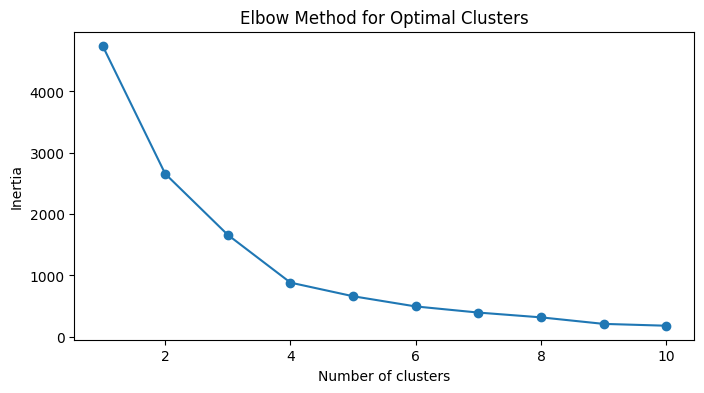

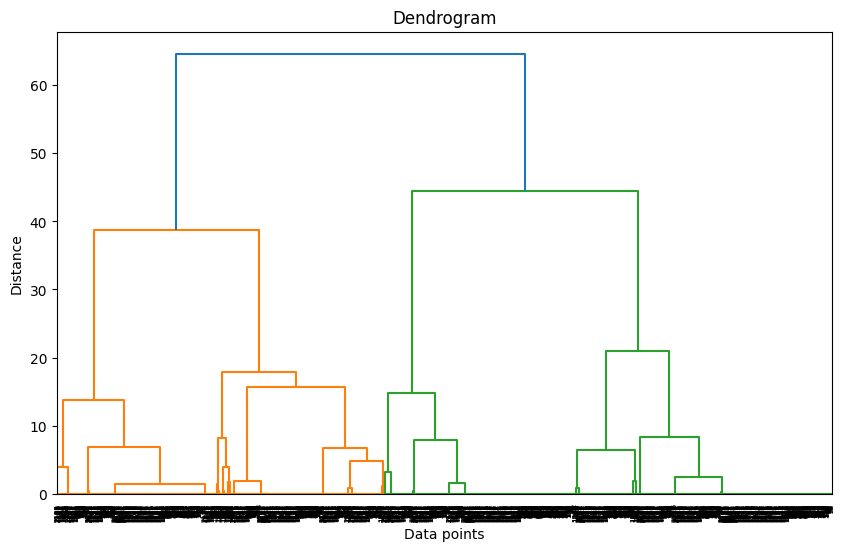

Test Case 1 passed!
Test case 2 passed!


In [32]:
def main(filepath):
    x = load_data(filepath)

    # Apply PCA for Dimensionality Reduction
    x_pca = apply_pca(x, n_components=2)
    
    # KMeans: finding optimal clusters
    inertia = find_optimal_clusters(x_pca)
    
    # KMeans clustering implementation
    y_kmeans = perform_kmeans_clustering(x_pca)
    
    # Agglomerative Clustering
    y_agglomerative = perform_agglomerative_clustering(x_pca)
    
    # Hierarchical Clustering Dendrogram
    hierarchical_linked = get_linkages(x_pca)
    
    # Plot the dendrogram for hierarchical clustering
    plot_dendrogram(hierarchical_linked)
    
    # Silhouette scores
    silhouette_kmeans = calculate_silhouette_score(x_pca, y_kmeans)
    silhouette_agglomerative = calculate_silhouette_score(x_pca, y_agglomerative)
    
    # Return results
    return {
        "inertia": inertia,
        "silhouette_kmeans": silhouette_kmeans,
        "silhouette_agglomerative": silhouette_agglomerative,
        "agglomerative_clustering": y_agglomerative,
        "hierarchical_linked": hierarchical_linked,
        "pca_components": x_pca
    }

# %%
# Call the main function and print silhouette scores and dendrogram
result = main("marketing_campaign.csv")


# Silhouette scores checks 
if result['silhouette_kmeans'] >= 0.5:
    print("Test Case 1 passed!")
if result['silhouette_agglomerative'] >= 0.5:
    print("Test case 2 passed!")